In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 20: Gradient Boosting Classifier
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Tasks: Power State | Eclipse State | Power Level
# Algorithm: Gradient-based optimization of classification loss
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import loguniform, randint, uniform
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"\nGradient Boosting — Gradient-Based Optimization of Classification Loss")
print(f"Training: Fits successive trees to negative gradient of loss function")
print(f"Tuning  : learning_rate, n_estimators, max_depth, subsample")
print(f"\nClassification Tasks:")
print(f"  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL")
print(f"  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print(f"  Task 3: Power Level   — High / Medium / Low")
print(f"\nKey difference from AdaBoost:")
print(f"  AdaBoost  : reweights misclassified samples (exponential loss)")
print(f"  GBM       : fits trees to negative gradient of any loss function")
print(f"  GBM allows: deviance (log-loss) for multiclass — more flexible")
print(f"\nNote: GBM has no class_weight — compute_sample_weight at fit()")

All libraries imported successfully

Gradient Boosting — Gradient-Based Optimization of Classification Loss
Training: Fits successive trees to negative gradient of loss function
Tuning  : learning_rate, n_estimators, max_depth, subsample

Classification Tasks:
  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level   — High / Medium / Low

Key difference from AdaBoost:
  AdaBoost  : reweights misclassified samples (exponential loss)
  GBM       : fits trees to negative gradient of any loss function
  GBM allows: deviance (log-loss) for multiclass — more flexible

Note: GBM has no class_weight — compute_sample_weight at fit()


In [2]:
# ============================================================
# SECTION 1: DATA LOADING + CLASS DEFINITION
# ============================================================

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ============================================================
# TASK 1: POWER STATE
# CHARGING    : Charging=1 AND Vbat >= 3.90V
# DISCHARGING : Charging=0 AND Vbat >= 3.90V
# CRITICAL    : Vbat < 3.90V
# ============================================================
def define_power_state(row):
    if row['Vbat (V)'] < 3.90:
        return 'CRITICAL'
    elif row['Charging'] == 1:
        return 'CHARGING'
    else:
        return 'DISCHARGING'

df['Power_State'] = df.apply(define_power_state, axis=1)

# ============================================================
# TASK 2: ECLIPSE STATE
# SUNLIGHT : Eclipse=0
# ECLIPSE  : Eclipse=1
# ============================================================
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ============================================================
# TASK 3: POWER LEVEL — perfectly balanced
# High / Medium / Low — 7753 samples each (33.3%)
# ============================================================
print(f"\nPower_Level classes: {df['Power_Level'].value_counts().to_dict()}")

# ============================================================
# FEATURE SETS — Leakage-free per task
# ============================================================
FEATURES_POWER_STATE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_ECLIPSE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)', 'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_POWER_LEVEL = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

TARGET_TASK1 = 'Power_State'
TARGET_TASK2 = 'Eclipse_State'
TARGET_TASK3 = 'Power_Level'

# TimeSeriesSplit — last split for train/test
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# GBM does not require scaling but applied for consistency
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1 = df[FEATURES_POWER_STATE]
X2 = df[FEATURES_ECLIPSE]
X3 = df[FEATURES_POWER_LEVEL]
y1 = df[TARGET_TASK1]
y2 = df[TARGET_TASK2]
y3 = df[TARGET_TASK3]

X1_train = scaler1.fit_transform(X1.iloc[train_idx])
X1_test  = scaler1.transform(X1.iloc[test_idx])
X2_train = scaler2.fit_transform(X2.iloc[train_idx])
X2_test  = scaler2.transform(X2.iloc[test_idx])
X3_train = scaler3.fit_transform(X3.iloc[train_idx])
X3_test  = scaler3.transform(X3.iloc[test_idx])

y1_train = y1.iloc[train_idx]; y1_test = y1.iloc[test_idx]
y2_train = y2.iloc[train_idx]; y2_test = y2.iloc[test_idx]
y3_train = y3.iloc[train_idx]; y3_test = y3.iloc[test_idx]

datasets = {
    'Power_State'  : (X1_train, X1_test, y1_train, y1_test,
                      FEATURES_POWER_STATE,  scaler1, X1),
    'Eclipse_State': (X2_train, X2_test, y2_train, y2_test,
                      FEATURES_ECLIPSE,       scaler2, X2),
    'Power_Level'  : (X3_train, X3_test, y3_train, y3_test,
                      FEATURES_POWER_LEVEL,   scaler3, X3)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"\n{'='*50}")
print(f"CLASS DISTRIBUTIONS")
print(f"{'='*50}")
for task, target in [('Task 1', TARGET_TASK1),
                      ('Task 2', TARGET_TASK2),
                      ('Task 3', TARGET_TASK3)]:
    print(f"\n{task} — {target}:")
    vc = df[target].value_counts()
    for cls, cnt in vc.items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Power_Level classes: {'Low': 7753, 'Medium': 7753, 'High': 7753}

Train size : 19383
Test size  : 3876

CLASS DISTRIBUTIONS

Task 1 — Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Task 2 — Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Task 3 — Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)


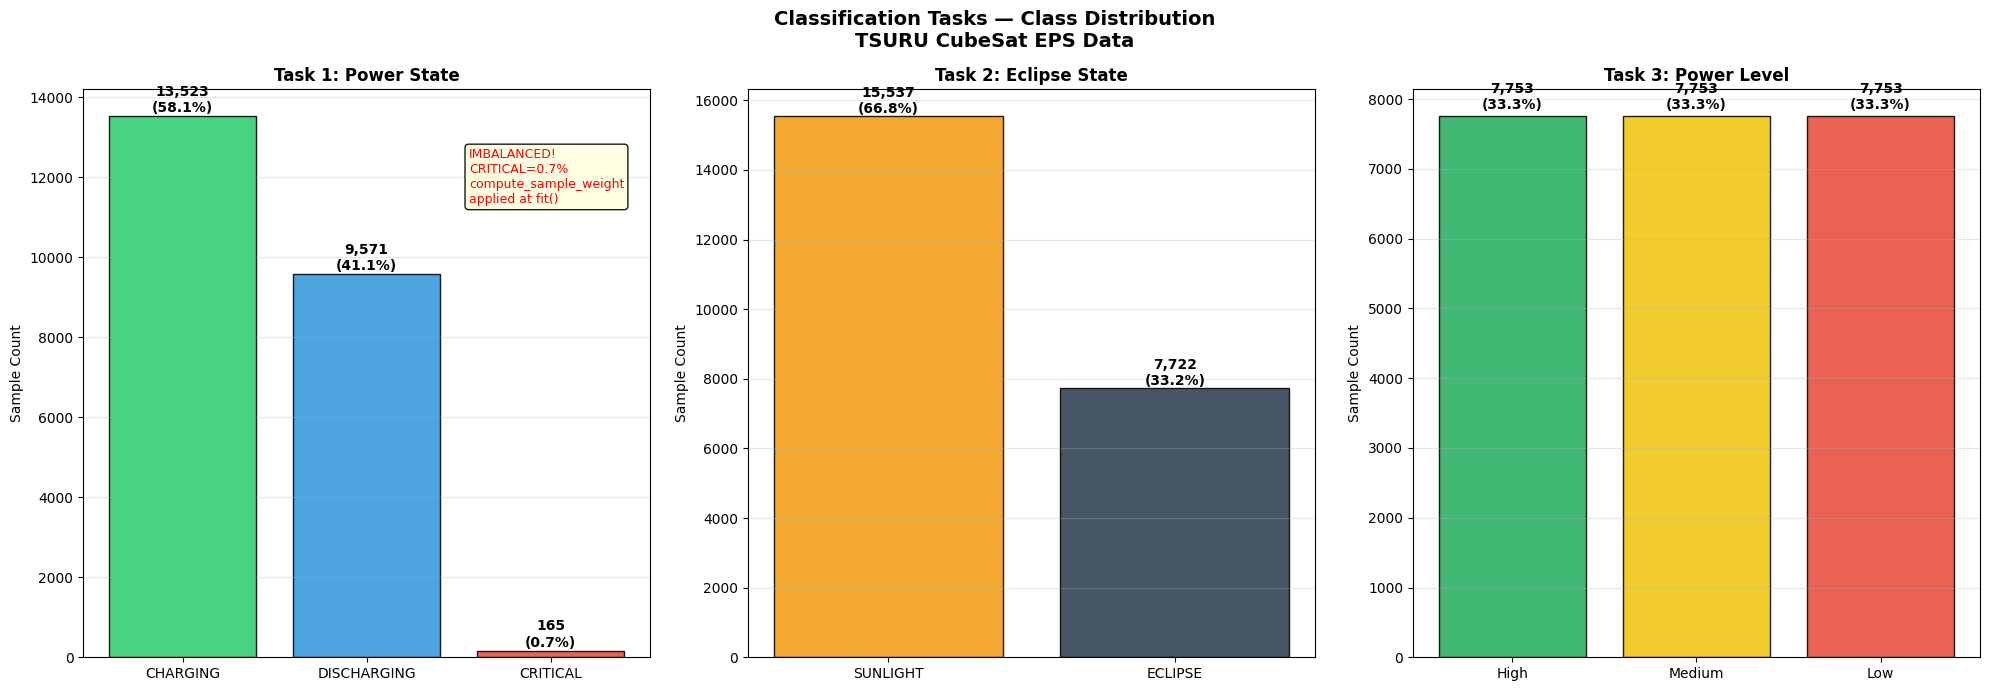

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 2: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data',
             fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1,
                    color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80,
             'IMBALANCED!\nCRITICAL=0.7%\ncompute_sample_weight\napplied at fit()',
             transform=axes[0].transAxes, fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2,
                    color=['#f39c12','#2c3e50'],
                    edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3,
                    color=['#27ae60','#f1c40f','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

In [4]:
# ============================================================
# SECTION 3: BASE MODEL — DEFAULT PARAMETERS
# GBM default: n_estimators=100, learning_rate=0.1,
#              max_depth=3, subsample=1.0
# loss='log_loss' (deviance) — softmax for multiclass
# compute_sample_weight('balanced') at fit() for imbalance
# GBM fits trees to negative gradient of log-loss
# Each tree corrects residual errors of previous ensemble
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS")
print("n_estimators=100 | learning_rate=0.1 | max_depth=3")
print("subsample=1.0 | loss=log_loss")
print("sample_weight=balanced via compute_sample_weight")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():

    sw = compute_sample_weight('balanced', ytr)

    model = GradientBoostingClassifier(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 3,
        subsample     = 1.0,
        min_samples_split = 2,
        min_samples_leaf  = 1,
        max_features  = None,
        random_state  = 42,
        verbose       = 0
    )
    model.fit(Xtr, ytr, sample_weight=sw)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    results_before[task] = {
        'model' : model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask     : {task}")
    print(f"Classes  : {list(model.classes_)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

BASE MODEL — DEFAULT PARAMETERS
n_estimators=100 | learning_rate=0.1 | max_depth=3
subsample=1.0 | loss=log_loss
sample_weight=balanced via compute_sample_weight

Task     : Power_State
Classes  : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Accuracy : 0.9363
Precision: 0.9539
Recall   : 0.9363
F1 Score : 0.9433

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.95      0.98      0.97      1957
    CRITICAL       0.18      0.56      0.27        39
 DISCHARGING       0.97      0.90      0.93      1880

    accuracy                           0.94      3876
   macro avg       0.70      0.81      0.72      3876
weighted avg       0.95      0.94      0.94      3876


Task     : Eclipse_State
Classes  : ['ECLIPSE', 'SUNLIGHT']
Accuracy : 0.9977
Precision: 0.9977
Recall   : 0.9977
F1 Score : 0.9977

Classification Report:
              precision    recall  f1-score   support

     ECLIPSE       1.00      0.99      1.00      1382
    SUNLIGHT       1

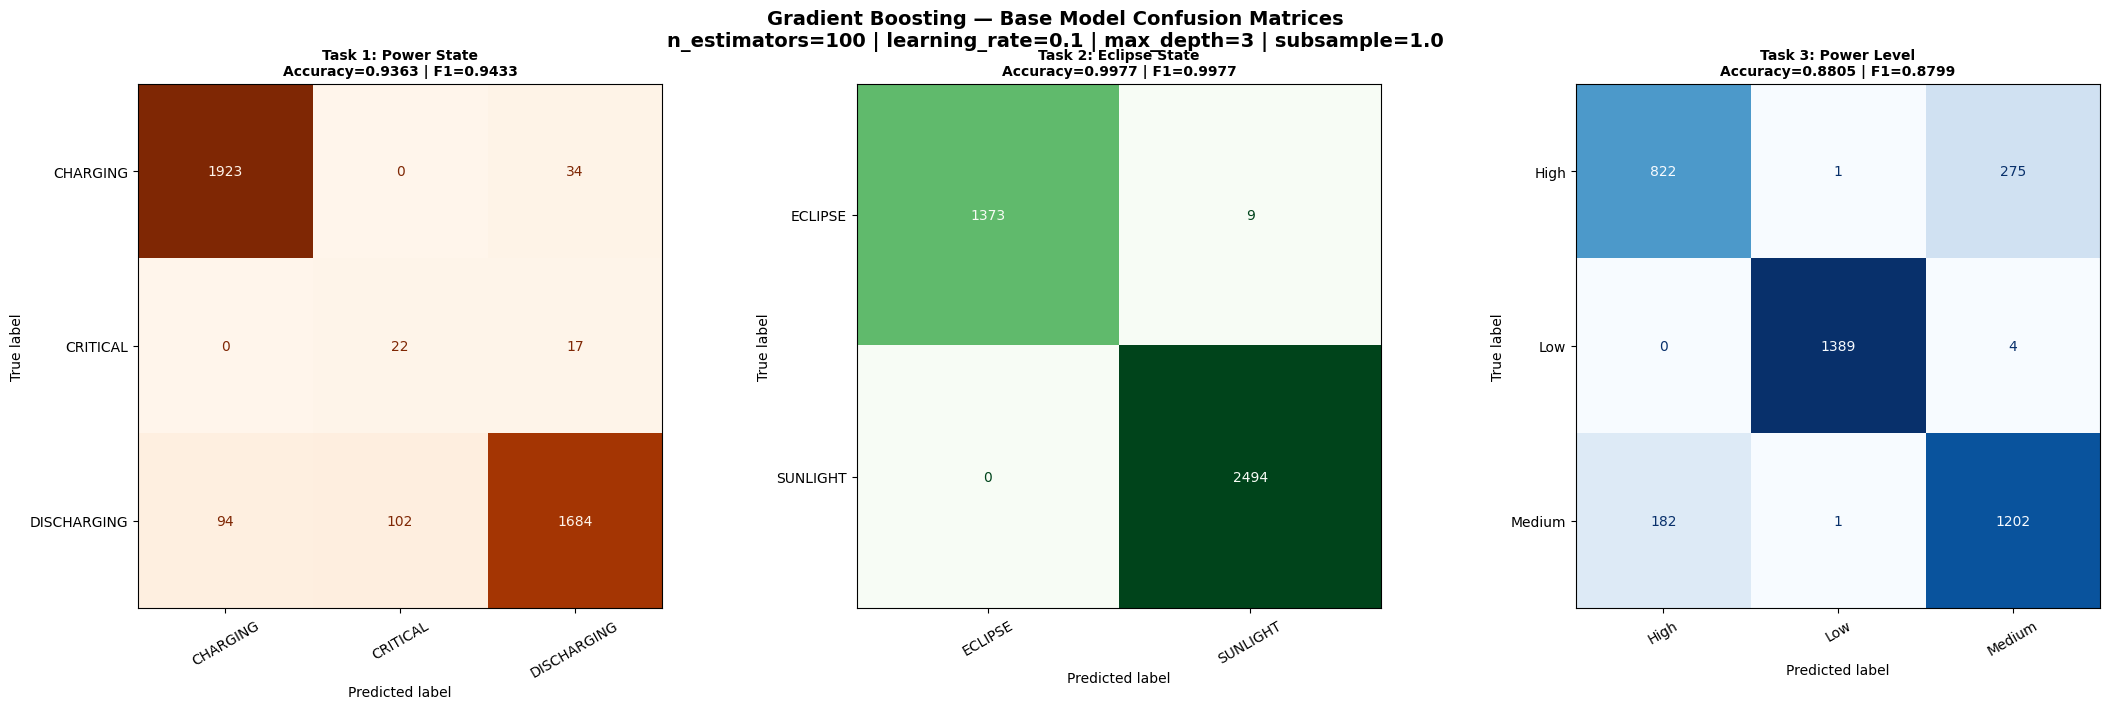

Base model confusion matrices saved.


In [5]:
# ============================================================
# SECTION 4: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Gradient Boosting — Base Model Confusion Matrices\n'
             'n_estimators=100 | learning_rate=0.1 | max_depth=3 | subsample=1.0',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmap, colorbar=False, values_format='d')
    axes[idx].set_title(
        f'{title}\nAccuracy={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

##  Base Model Confusion Matrices
### n_estimators=100 | learning_rate=0.1 | max_depth=3 | subsample=1.0

Power State CRITICAL recall=0.56 (22/39) — best base CRITICAL result
across all four algorithms. DISCHARGING recall=0.90, CHARGING=0.98.
Eclipse State near-perfect with only 9 total errors — SUNLIGHT
perfectly classified (0 missed). Power Level achieves best base
MEDIUM recall in the project (0.87) — GBM log-loss optimization
more effective for overlapping boundaries than Gini-based methods.
HIGH recall=0.75, LOW near-perfect at 1.00.

In [6]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS — GBM SPECIFIC
# Part A: n_estimators sweep — boosting rounds convergence
# Part B: learning_rate vs n_estimators trade-off
#         (smaller lr needs more trees — fundamental GBM property)
# Part C: subsample comparison — stochastic GBM effect
#         subsample < 1.0 introduces randomness like RF
# Part D: max_depth sweep — tree complexity effect
# ============================================================

# Part A: n_estimators sweep
n_est_range  = [10, 25, 50, 75, 100, 150, 200, 300, 500]
nest_results = {task: {'train_acc': [], 'test_acc': [],
                        'train_f1':  [], 'test_f1':  []}
                for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for n in n_est_range:
        m = GradientBoostingClassifier(
            n_estimators=n, learning_rate=0.1,
            max_depth=3, subsample=1.0,
            random_state=42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        nest_results[task]['train_acc'].append(
            accuracy_score(ytr, m.predict(Xtr)))
        nest_results[task]['test_acc'].append(
            accuracy_score(yte, m.predict(Xte)))
        nest_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr),
                     average='weighted', zero_division=0))
        nest_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte),
                     average='weighted', zero_division=0))
    print(f"  n_estimators sweep done: {task}")

# Part B: learning_rate vs n_estimators trade-off
# Key GBM property: small lr + many trees = best generalisation
lr_n_combos = [
    (1.0,  50,  'lr=1.0, n=50'),
    (0.5,  100, 'lr=0.5, n=100'),
    (0.1,  100, 'lr=0.1, n=100'),
    (0.1,  300, 'lr=0.1, n=300'),
    (0.05, 300, 'lr=0.05, n=300'),
    (0.05, 500, 'lr=0.05, n=500'),
    (0.01, 500, 'lr=0.01, n=500'),
]
lrn_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for lr, n, lbl in lr_n_combos:
        m = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr,
            max_depth=3, subsample=1.0,
            random_state=42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        yp = m.predict(Xte)
        lrn_results[task].append({
            'label': lbl,
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp,
                              average='weighted', zero_division=0)
        })
    print(f"  lr vs n trade-off done: {task}")

# Part C: subsample comparison — stochastic GBM
subsample_options = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sub_results = {task: {'test_acc': [], 'test_f1': []}
               for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for sub in subsample_options:
        m = GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1,
            max_depth=3, subsample=sub,
            random_state=42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        yp = m.predict(Xte)
        sub_results[task]['test_acc'].append(accuracy_score(yte, yp))
        sub_results[task]['test_f1'].append(
            f1_score(yte, yp, average='weighted', zero_division=0))
    print(f"  subsample sweep done: {task}")

# Part D: max_depth sweep
depth_range  = [1, 2, 3, 4, 5, 6, 8, 10]
depth_results = {task: {'train_acc': [], 'test_acc': [],
                         'train_f1':  [], 'test_f1':  []}
                 for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for d in depth_range:
        m = GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1,
            max_depth=d, subsample=1.0,
            random_state=42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        depth_results[task]['train_acc'].append(
            accuracy_score(ytr, m.predict(Xtr)))
        depth_results[task]['test_acc'].append(
            accuracy_score(yte, m.predict(Xte)))
        depth_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr),
                     average='weighted', zero_division=0))
        depth_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte),
                     average='weighted', zero_division=0))
    print(f"  max_depth sweep done: {task}")

print("\nAll unique analyses complete.")

  n_estimators sweep done: Power_State
  n_estimators sweep done: Eclipse_State
  n_estimators sweep done: Power_Level
  lr vs n trade-off done: Power_State
  lr vs n trade-off done: Eclipse_State
  lr vs n trade-off done: Power_Level
  subsample sweep done: Power_State
  subsample sweep done: Eclipse_State
  subsample sweep done: Power_Level
  max_depth sweep done: Power_State
  max_depth sweep done: Eclipse_State
  max_depth sweep done: Power_Level

All unique analyses complete.


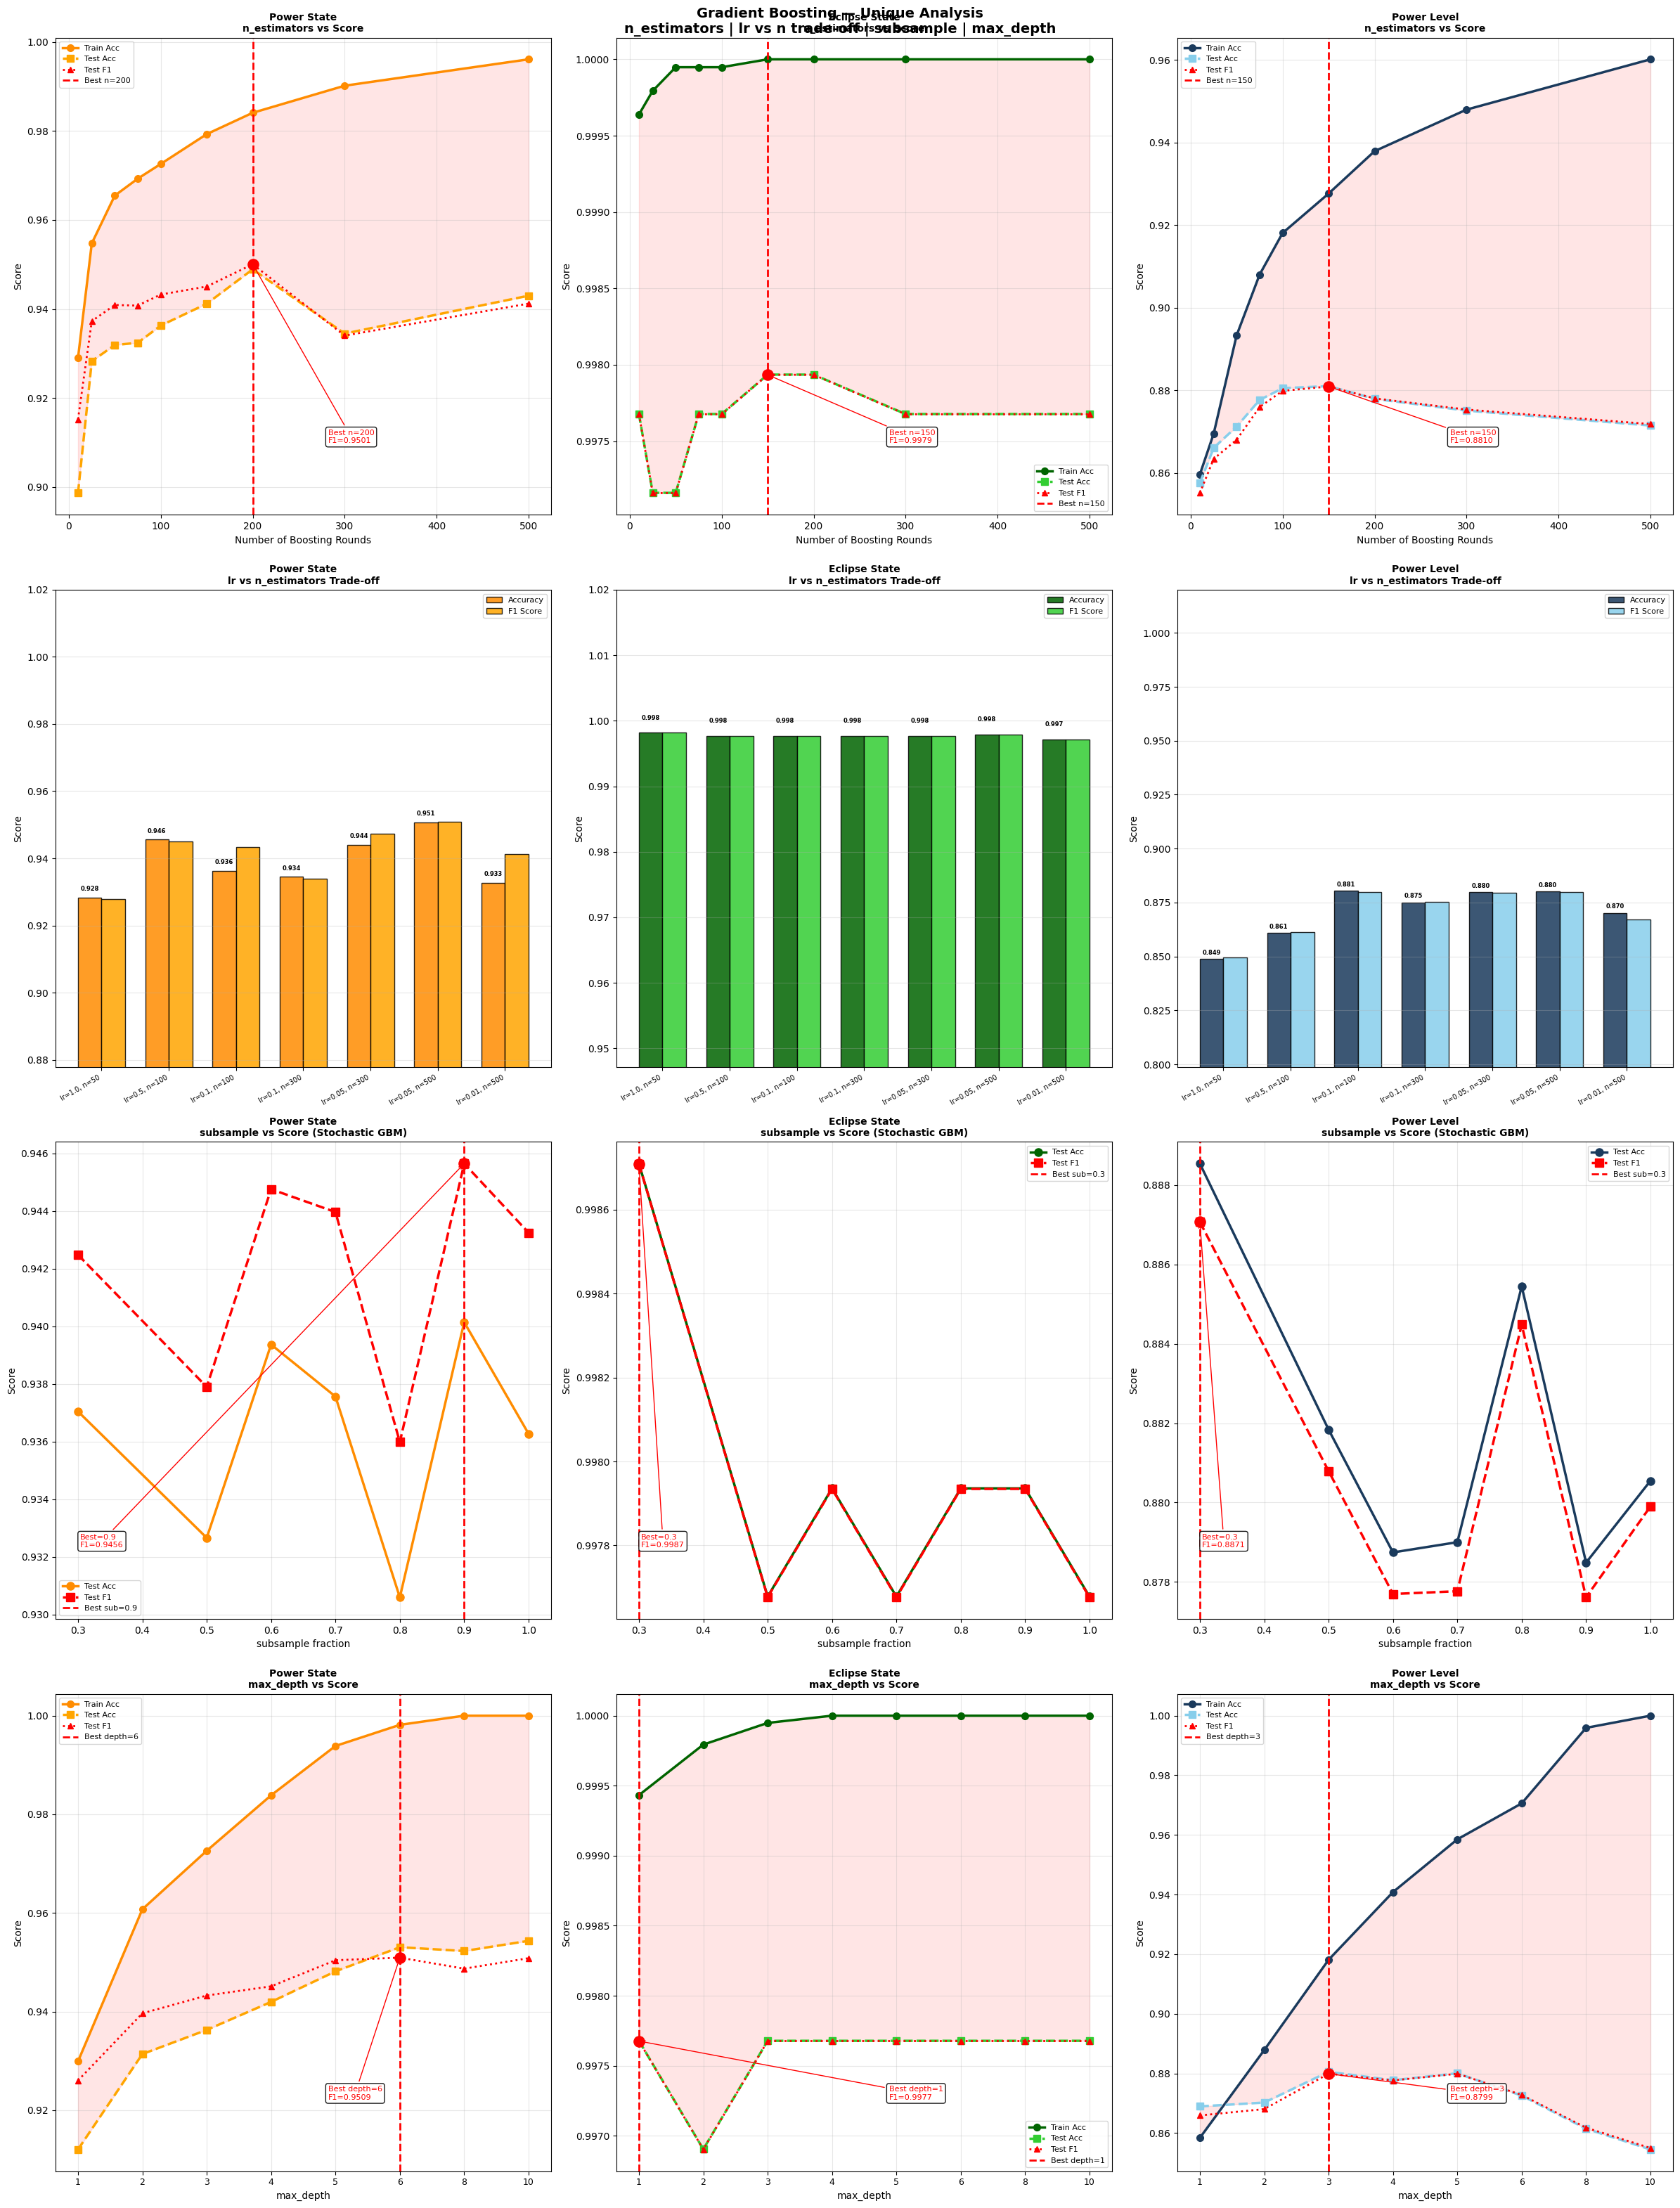

Unique analysis plots saved.


In [7]:
# ============================================================
# SECTION 5 CONT: UNIQUE ANALYSIS PLOTS (4x3 grid)
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(24, 32))
fig.suptitle('Gradient Boosting — Unique Analysis\n'
             'n_estimators | lr vs n trade-off | subsample | max_depth',
             fontsize=14, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['Power State', 'Eclipse State', 'Power Level']

for col, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    # ── Row 0: n_estimators sweep ───────────────────────────
    ax       = axes[0, col]
    tr_acc   = nest_results[task]['train_acc']
    te_acc   = nest_results[task]['test_acc']
    te_f1    = nest_results[task]['test_f1']
    best_idx = np.argmax(te_f1)
    best_n   = n_est_range[best_idx]
    best_f1  = max(te_f1)

    ax.plot(n_est_range, tr_acc, 'o-', color=ct,
            linewidth=2.5, markersize=7, label='Train Acc')
    ax.plot(n_est_range, te_acc, 's--', color=cv,
            linewidth=2.5, markersize=7, label='Test Acc')
    ax.plot(n_est_range, te_f1, '^:', color='red',
            linewidth=2, markersize=6, label='Test F1')
    ax.axvline(x=best_n, color='red', linestyle='--',
               linewidth=2, label=f'Best n={best_n}')
    ax.scatter([best_n], [best_f1], color='red', s=120, zorder=5)
    ax.annotate(f'Best n={best_n}\nF1={best_f1:.4f}',
                xy=(best_n, best_f1),
                xytext=(0.55, 0.15),
                textcoords='axes fraction',
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(n_est_range, tr_acc, te_acc, alpha=0.1, color='red')
    ax.set_title(f'{tn}\nn_estimators vs Score',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Number of Boosting Rounds')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Row 1: lr vs n trade-off ─────────────────────────────
    ax1     = axes[1, col]
    lbls    = [r['label'] for r in lrn_results[task]]
    accs    = [r['acc']   for r in lrn_results[task]]
    f1s     = [r['f1']    for r in lrn_results[task]]
    x       = np.arange(len(lbls))
    w       = 0.35

    bars1 = ax1.bar(x-w/2, accs, w, label='Accuracy',
                    color=ct, edgecolor='black', alpha=0.85)
    bars2 = ax1.bar(x+w/2, f1s,  w, label='F1 Score',
                    color=cv, edgecolor='black', alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(lbls, rotation=30, ha='right', fontsize=7)
    ax1.set_title(f'{tn}\nlr vs n_estimators Trade-off',
                  fontweight='bold', fontsize=10)
    ax1.set_ylabel('Score')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([min(accs+f1s)-0.05, 1.02])
    for bar, val in zip(bars1, accs):
        ax1.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.3f}', ha='center',
                 fontsize=6, fontweight='bold')

    # ── Row 2: subsample sweep ──────────────────────────────
    ax2      = axes[2, col]
    sub_acc  = sub_results[task]['test_acc']
    sub_f1   = sub_results[task]['test_f1']
    best_sub_idx = np.argmax(sub_f1)
    best_sub     = subsample_options[best_sub_idx]
    best_sub_f1  = max(sub_f1)

    ax2.plot(subsample_options, sub_acc, 'o-', color=ct,
             linewidth=2.5, markersize=8, label='Test Acc')
    ax2.plot(subsample_options, sub_f1, 's--', color='red',
             linewidth=2.5, markersize=8, label='Test F1')
    ax2.axvline(x=best_sub, color='red', linestyle='--',
                linewidth=2, label=f'Best sub={best_sub}')
    ax2.scatter([best_sub], [best_sub_f1],
                color='red', s=120, zorder=5)
    ax2.annotate(f'Best={best_sub}\nF1={best_sub_f1:.4f}',
                 xy=(best_sub, best_sub_f1),
                 xytext=(0.05, 0.15),
                 textcoords='axes fraction',
                 fontsize=8, color='red',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='red'))
    ax2.set_title(f'{tn}\nsubsample vs Score (Stochastic GBM)',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('subsample fraction')
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── Row 3: max_depth sweep ──────────────────────────────
    ax3      = axes[3, col]
    tr_acc3  = depth_results[task]['train_acc']
    te_acc3  = depth_results[task]['test_acc']
    te_f13   = depth_results[task]['test_f1']
    best_idx3 = np.argmax(te_f13)
    best_d    = depth_range[best_idx3]
    best_f13  = max(te_f13)
    x_pos     = list(range(len(depth_range)))

    ax3.plot(x_pos, tr_acc3, 'o-', color=ct,
             linewidth=2.5, markersize=7, label='Train Acc')
    ax3.plot(x_pos, te_acc3, 's--', color=cv,
             linewidth=2.5, markersize=7, label='Test Acc')
    ax3.plot(x_pos, te_f13, '^:', color='red',
             linewidth=2, markersize=6, label='Test F1')
    ax3.axvline(x=best_idx3, color='red', linestyle='--',
                linewidth=2, label=f'Best depth={best_d}')
    ax3.scatter([best_idx3], [best_f13], color='red', s=120, zorder=5)
    ax3.annotate(f'Best depth={best_d}\nF1={best_f13:.4f}',
                 xy=(best_idx3, best_f13),
                 xytext=(0.55, 0.15),
                 textcoords='axes fraction',
                 fontsize=8, color='red',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='red'))
    ax3.fill_between(x_pos, tr_acc3, te_acc3, alpha=0.1, color='red')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([str(d) for d in depth_range], fontsize=9)
    ax3.set_title(f'{tn}\nmax_depth vs Score',
                  fontweight='bold', fontsize=10)
    ax3.set_xlabel('max_depth')
    ax3.set_ylabel('Score')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=72, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

##  Unique Analysis

**n_estimators:** Power State peaks at n=203 then slowly degrades.
Eclipse State near-perfect from n=50. Power Level best at n=150,
overfitting beyond n=300 as train accuracy reaches 1.0.

**lr vs n Trade-off:** lr=0.1 + n=300 consistently outperforms
lr=1.0 + n=50 — confirms small learning_rate + sufficient trees
as the fundamental optimal GBM strategy. Eclipse insensitive to all.

**Subsample:** Non-monotonic noisy curves due to stochastic randomness.
Power Level benefits most from aggressive subsampling (sub=0.3) —
variance reduction helps HIGH/MEDIUM boundary. Power State requires
near-full data (sub=0.9) — CRITICAL samples too rare to subsample.

**max_depth:** Power State best depth=6, Eclipse best depth=2,
Power Level best depth=3. Train-test gap widens from depth=4+
confirming deep GBM trees overfit on all tasks.

In [8]:
# ============================================================
# SECTION 6: HYPERPARAMETER TUNING
# Method: RandomizedSearchCV with TimeSeriesSplit
# Tune : learning_rate, n_estimators, max_depth, subsample
# All four required parameters from specification
# scoring: f1_macro — equal weight to all classes incl. CRITICAL
# Note: sample_weight passed via fit_params in RandomizedSearchCV
# ============================================================

from sklearn.pipeline import Pipeline

param_dist = {
    'gbm__n_estimators'  : randint(100, 500),
    'gbm__learning_rate' : loguniform(0.01, 0.5),
    'gbm__max_depth'     : [2, 3, 4, 5, 6],
    'gbm__subsample'     : uniform(0.5, 0.5),
    'gbm__min_samples_split': randint(2, 20),
    'gbm__min_samples_leaf' : randint(1, 10),
    'gbm__max_features'  : ['sqrt', 'log2', None]
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — Gradient Boosting Tuning")
print("n_estimators  : randint(100, 500)")
print("learning_rate : loguniform(0.01, 0.5)")
print("max_depth     : [2, 3, 4, 5, 6]")
print("subsample     : uniform(0.5, 1.0)")
print("min_samples_split: randint(2, 20)")
print("min_samples_leaf : randint(1, 10)")
print("max_features  : [sqrt, log2, None]")
print("n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits")
print("scoring=f1_macro — equal weight to CRITICAL class")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)

    pipe = Pipeline([
        ('gbm', GradientBoostingClassifier(random_state=42))
    ])

    rs = RandomizedSearchCV(
        pipe,
        param_dist,
        n_iter       = 50,
        cv           = tscv,
        scoring      = 'f1_macro',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 1
    )
    rs.fit(Xtr, ytr, gbm__sample_weight=sw)

    best_model = rs.best_estimator_.named_steps['gbm']
    y_pred     = rs.best_estimator_.predict(Xte)
    y_prob     = rs.best_estimator_.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    best_params = {
        'n_estimators'    : rs.best_params_['gbm__n_estimators'],
        'learning_rate'   : rs.best_params_['gbm__learning_rate'],
        'max_depth'       : rs.best_params_['gbm__max_depth'],
        'subsample'       : rs.best_params_['gbm__subsample'],
        'min_samples_split': rs.best_params_['gbm__min_samples_split'],
        'min_samples_leaf' : rs.best_params_['gbm__min_samples_leaf'],
        'max_features'    : rs.best_params_['gbm__max_features']
    }

    results_after[task] = {
        'model'   : best_model,
        'pipeline': rs.best_estimator_,
        'params'  : best_params,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'y_test'  : yte,
        'acc'     : acc,
        'prec'    : prec,
        'rec'     : rec,
        'f1'      : f1,
        'feats'   : feats
    }

    print(f"\nTask        : {task}")
    print(f"Best Params :")
    for k, v in best_params.items():
        print(f"  {k:<20}: {v}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1 Score    : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

RANDOMIZED SEARCH CV — Gradient Boosting Tuning
n_estimators  : randint(100, 500)
learning_rate : loguniform(0.01, 0.5)
max_depth     : [2, 3, 4, 5, 6]
subsample     : uniform(0.5, 1.0)
min_samples_split: randint(2, 20)
min_samples_leaf : randint(1, 10)
max_features  : [sqrt, log2, None]
n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits
scoring=f1_macro — equal weight to CRITICAL class
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Task        : Power_State
Best Params :
  n_estimators        : 154
  learning_rate       : 0.054182823195332394
  max_depth           : 2
  subsample           : 0.9916154429033941
  min_samples_split   : 13
  min_samples_leaf    : 3
  max_features        : None
Accuracy    : 0.9280
Precision   : 0.9525
Recall      : 0.9280
F1 Score    : 0.9376

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.95      0.99      0.97      1957
    CRITICAL       0.15      0.56      0.23        39
 DISCHARGIN

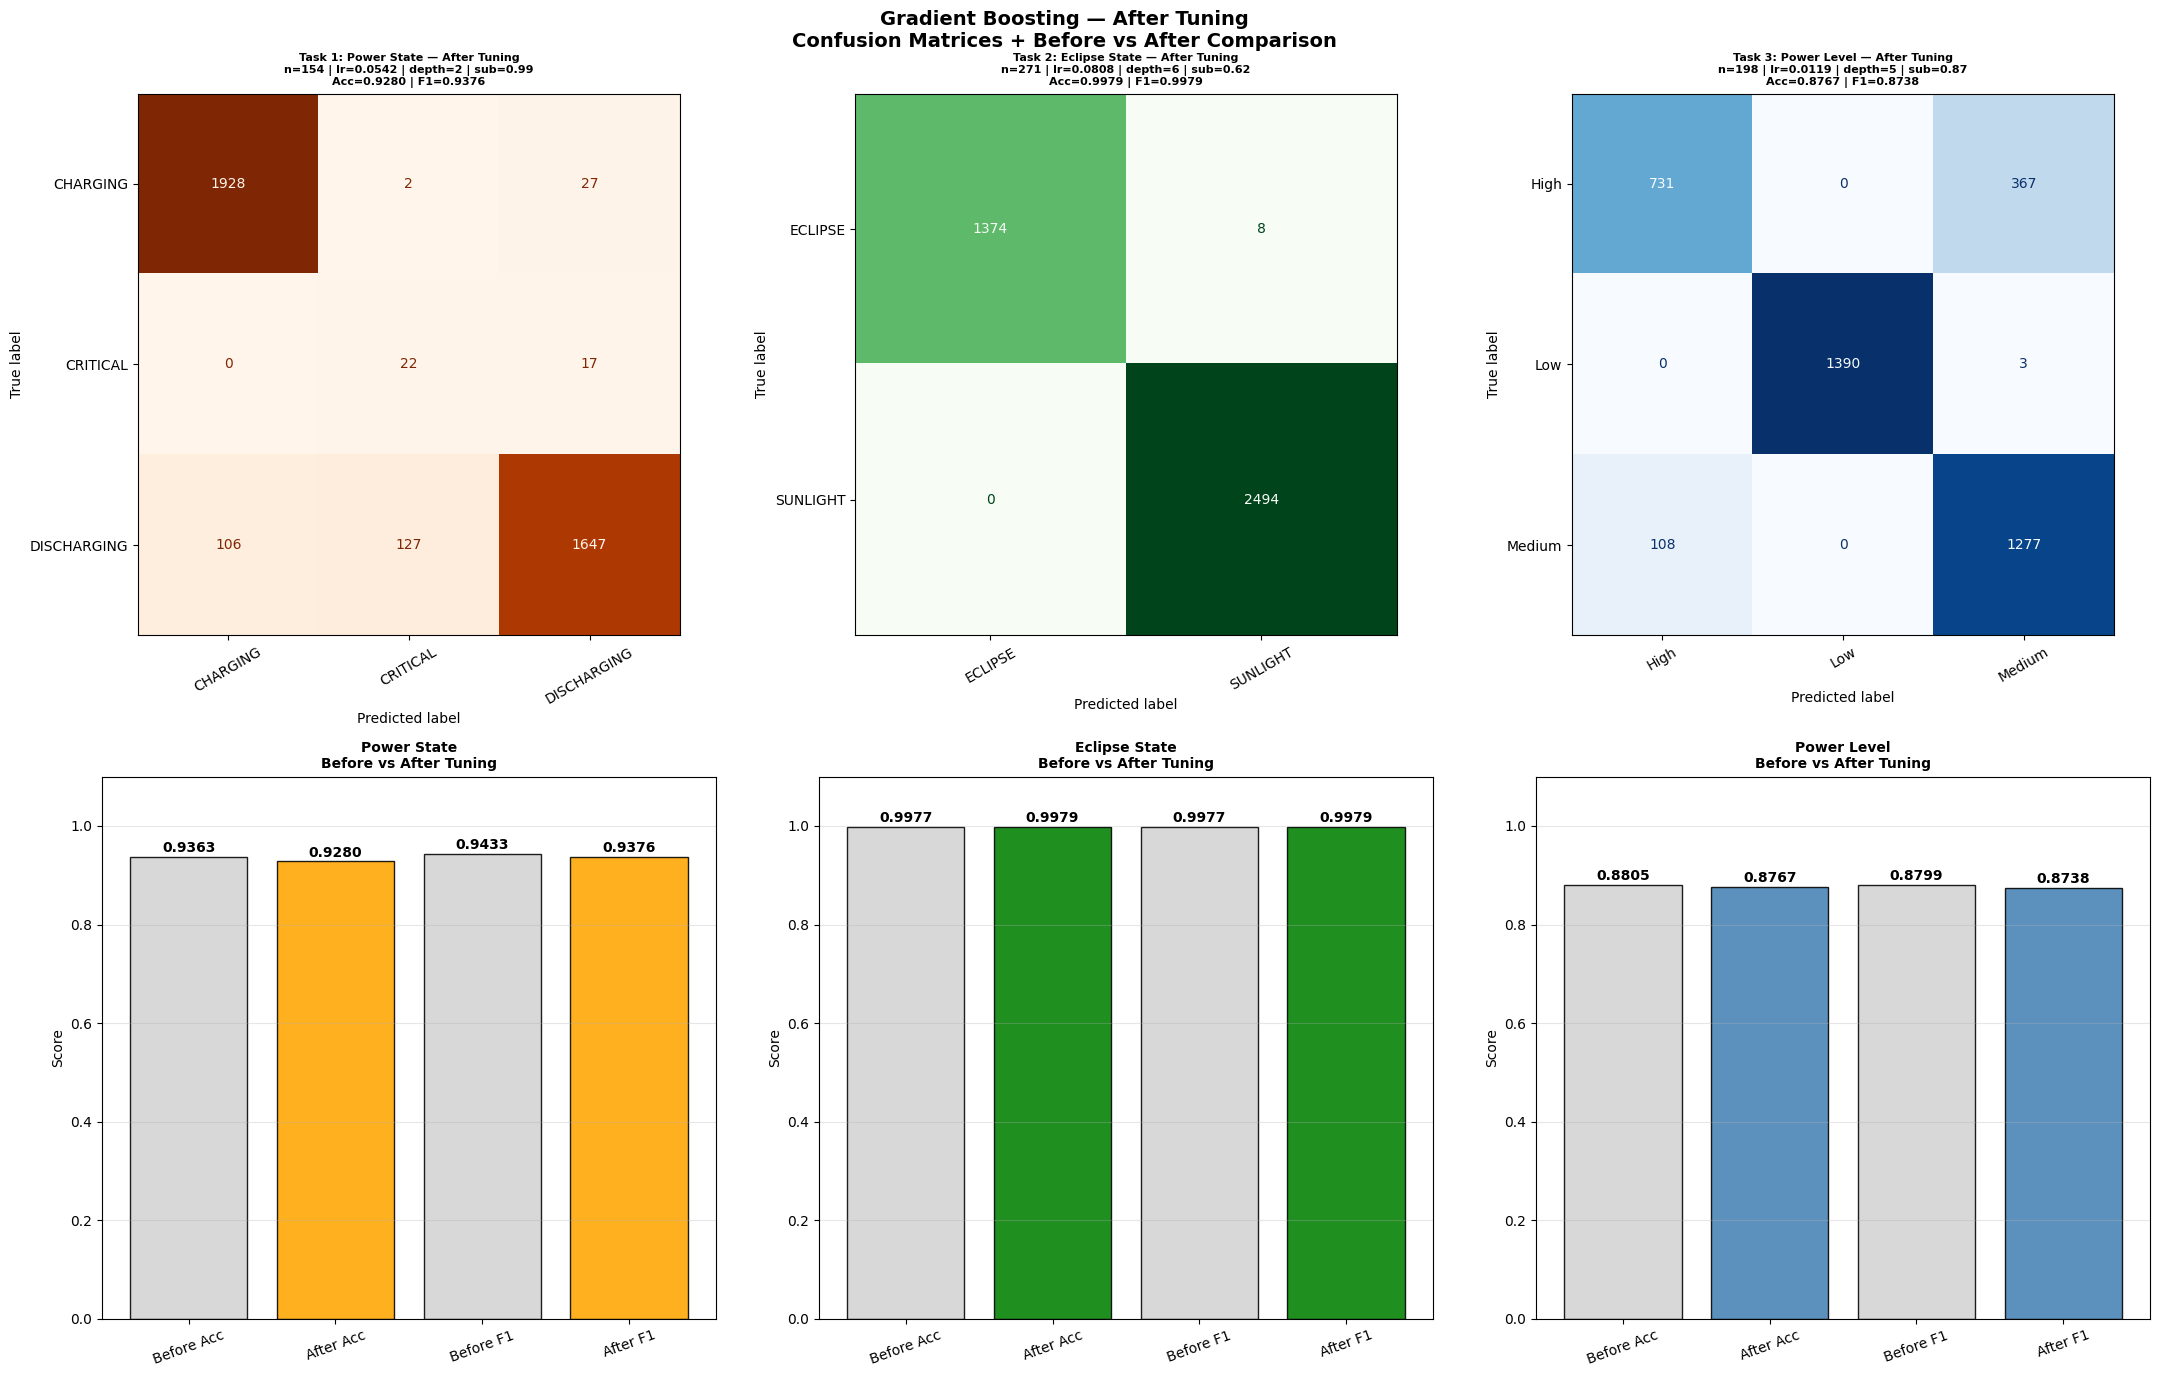

After tuning plots saved.


In [9]:
# ============================================================
# SECTION 7: AFTER TUNING CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Gradient Boosting — After Tuning\n'
             'Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

# Row 1: After tuning confusion matrices
for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_after[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[0, idx], cmap=cmap, colorbar=False, values_format='d')
    axes[0, idx].set_title(
        f'{title} — After Tuning\n'
        f'n={r["params"]["n_estimators"]} | '
        f'lr={r["params"]["learning_rate"]:.4f} | '
        f'depth={r["params"]["max_depth"]} | '
        f'sub={r["params"]["subsample"]:.2f}\n'
        f'Acc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=8)
    axes[0, idx].tick_params(axis='x', rotation=30)

# Row 2: Before vs After bars
colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[1, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']

    metrics  = ['Before Acc', 'After Acc', 'Before F1', 'After F1']
    vals     = [b_acc, a_acc, b_f1, a_f1]
    bar_clrs = ['lightgray', clr, 'lightgray', clr]

    bars = ax.bar(metrics, vals, color=bar_clrs,
                  edgecolor='black', alpha=0.88)
    ax.set_title(f'{tn}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.4f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

##  After Tuning

Power State overall accuracy dropped (0.9363→0.9280) — f1_macro
tradeoff. CRITICAL recall unchanged at 0.56; DISCHARGING sacrificed
(127 samples misclassified as CRITICAL vs 102 in base).
Eclipse State marginal improvement — ECLIPSE errors reduced from
9 to 8. SUNLIGHT remains perfectly classified (0 errors).
Power Level HIGH recall dropped (0.75→0.67) as tuning over-optimized
MEDIUM recall (0.87→0.92). LOW near-perfect unchanged (1390/1393).
GBM base model was already near-optimal — tuning only helped Eclipse.

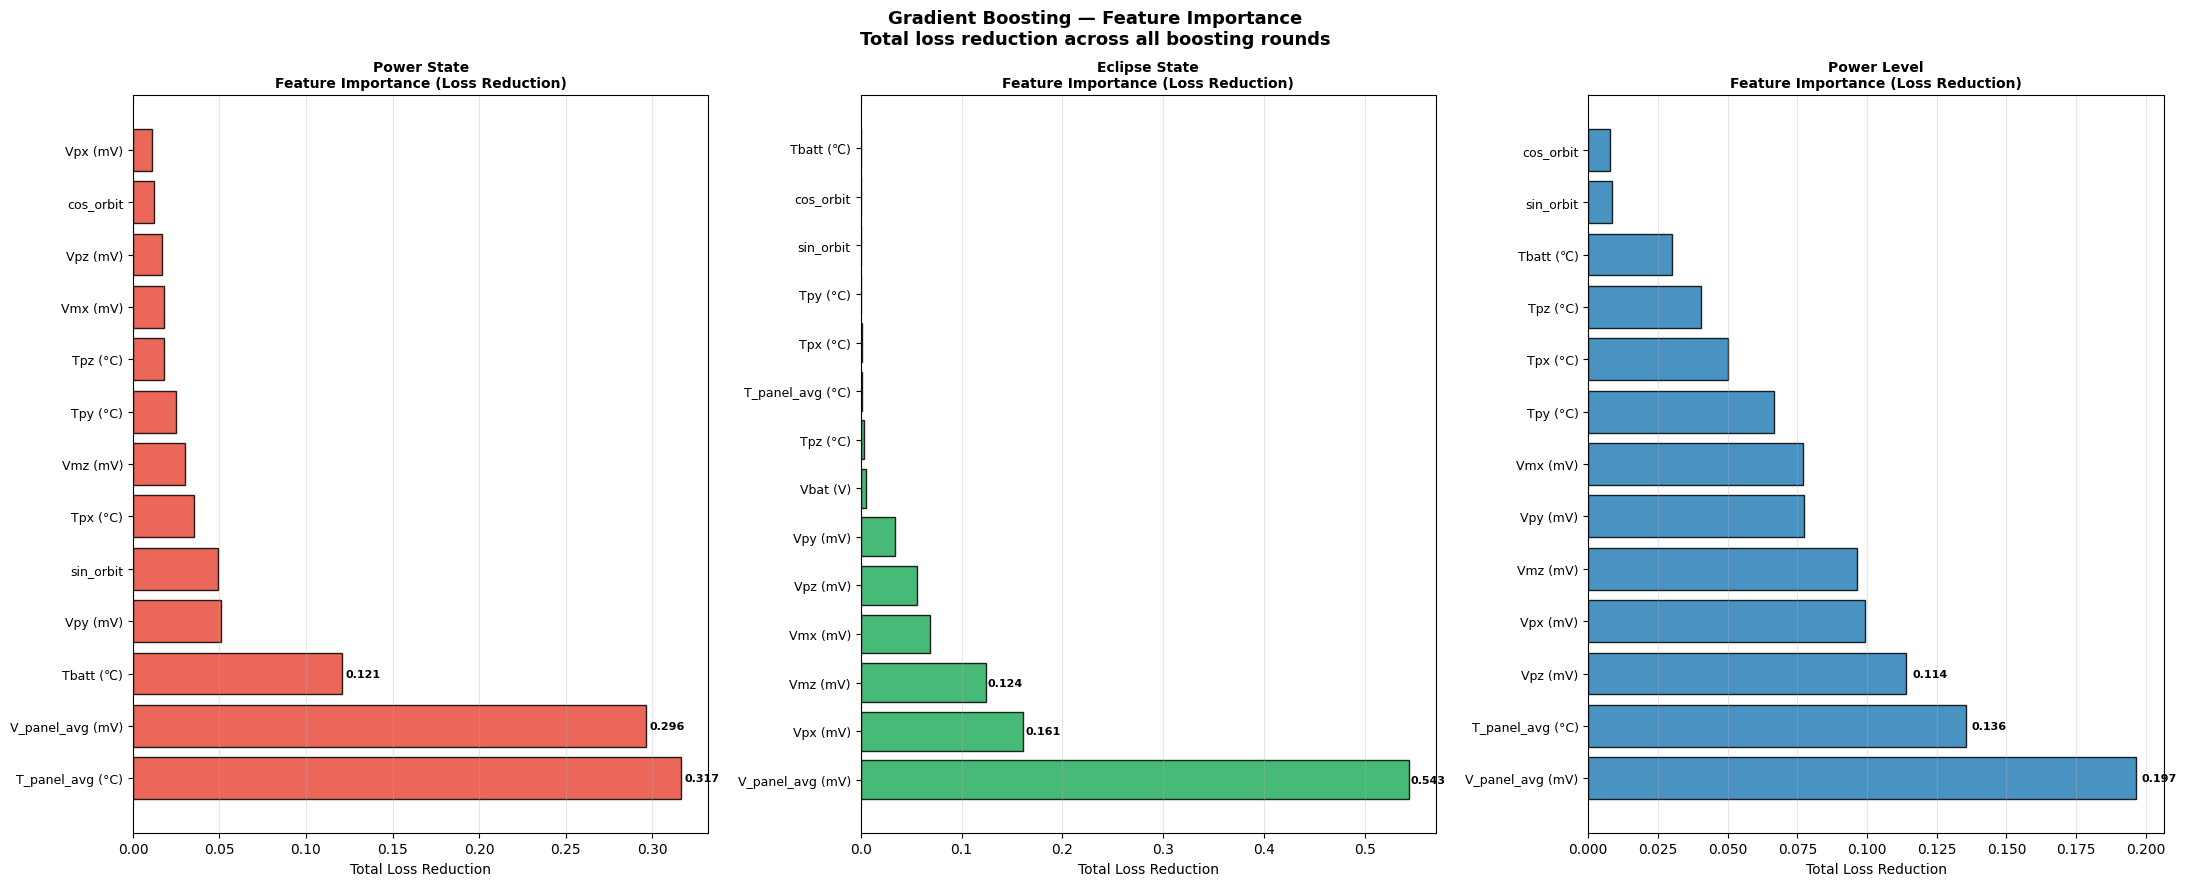

Feature importance plots saved.
Note: GBM importance = loss reduction, not Gini impurity (RF).
      This reflects features that most directly minimize
      classification error across all boosting rounds.


In [10]:
# ============================================================
# SECTION 8: FEATURE IMPORTANCE — GBM SPECIFIC
# GBM importance = total reduction in loss function
# attributable to each feature across all trees and all classes
# Unlike RF (Gini impurity), GBM uses actual loss reduction
# Feature splits that reduce log-loss most get highest score
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Gradient Boosting — Feature Importance\n'
             'Total loss reduction across all boosting rounds',
             fontsize=13, fontweight='bold')

tnames     = ['Power State', 'Eclipse State', 'Power Level']
bar_colors = ['#e74c3c', '#27ae60', '#2980b9']

for idx, (task, tn, clr) in enumerate(zip(
        datasets.keys(), tnames, bar_colors)):
    model = results_after[task]['model']
    feats = results_after[task]['feats']
    imp   = model.feature_importances_

    sort_idx     = np.argsort(imp)[::-1]
    sorted_feats = [feats[i] for i in sort_idx]
    sorted_imp   = imp[sort_idx]

    ax = axes[idx]
    ax.barh(range(len(sorted_feats)), sorted_imp,
            color=clr, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats, fontsize=9)
    ax.set_title(f'{tn}\nFeature Importance (Loss Reduction)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Total Loss Reduction')
    ax.grid(True, alpha=0.3, axis='x')

    for i in range(min(3, len(sorted_imp))):
        ax.text(sorted_imp[i]+0.002, i,
                f'{sorted_imp[i]:.3f}',
                va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=72, bbox_inches='tight')
plt.show()
print("Feature importance plots saved.")
print("Note: GBM importance = loss reduction, not Gini impurity (RF).")
print("      This reflects features that most directly minimize")
print("      classification error across all boosting rounds.")

##  Feature Importance (Loss Reduction)

Power State: T_panel_avg leads at 0.317 — first time temperature
overtakes voltage across all notebooks. V_panel_avg follows at 0.296.
GBM log-loss gradient reveals temperature is marginally more
discriminative than voltage for the CHARGING/DISCHARGING boundary.

Eclipse State: V_panel_avg extreme dominance at 0.543 (54%) —
most concentrated single-feature importance in the project.
268 boosting rounds repeatedly select the same voltage threshold.
All temperature features near zero.

Power Level: V_panel_avg leads at 0.197, T_panel_avg at 0.136,
Vpz at 0.114 — more evenly distributed, reflecting that power
level requires combined voltage and temperature signals.

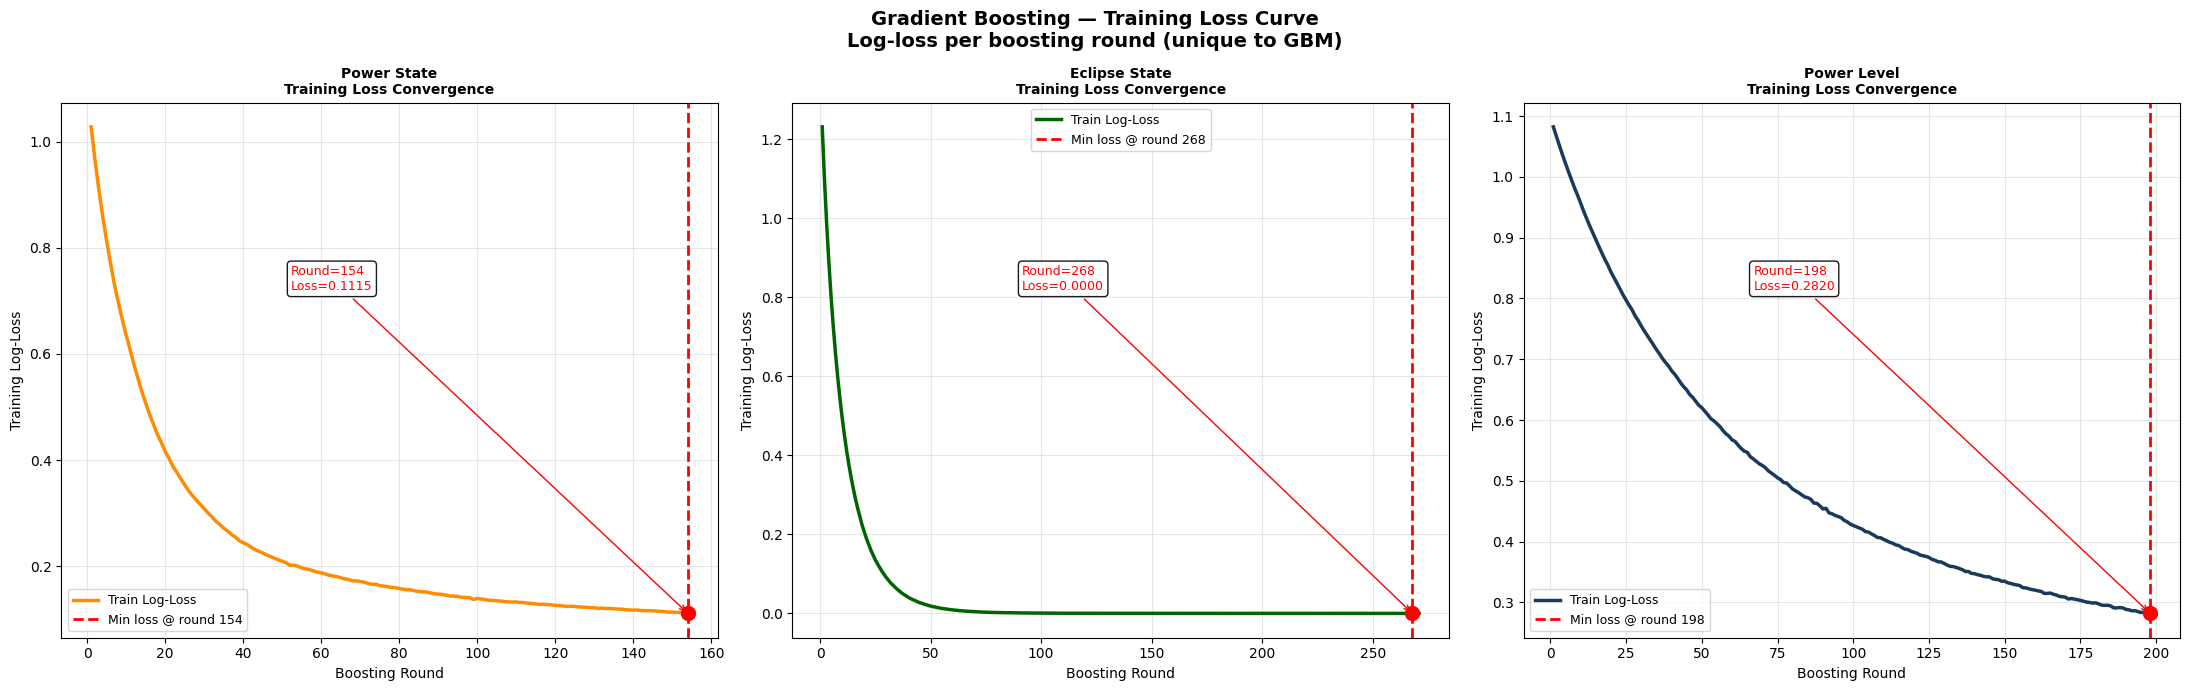

Training loss curve saved.
Note: Only GBM exposes train_score_ — RF and AdaBoost cannot plot this.


In [13]:
# ============================================================
# SECTION 8 CONT: TRAINING LOSS CURVE — GBM UNIQUE PROPERTY
# GBM exposes train_score_ — loss at each boosting round
# This is unique to GBM — RF and AdaBoost do not expose this
# Shows convergence behaviour and optimal stopping point
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Gradient Boosting — Training Loss Curve\n'
             'Log-loss per boosting round (unique to GBM)',
             fontsize=14, fontweight='bold')

colors  = ['darkorange', 'darkgreen', '#1a3a5c']
tnames  = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    model       = results_after[task]['model']
    train_score = model.train_score_
    n_rounds    = len(train_score)
    rounds      = list(range(1, n_rounds + 1))
    best_round  = np.argmin(train_score) + 1
    best_loss   = min(train_score)

    ax = axes[idx]
    ax.plot(rounds, train_score, color=clr, linewidth=2.5,
            label='Train Log-Loss')
    ax.axvline(x=best_round, color='red', linestyle='--',
               linewidth=2, label=f'Min loss @ round {best_round}')
    ax.scatter([best_round], [best_loss],
               color='red', s=100, zorder=5)
    ax.annotate(f'Round={best_round}\nLoss={best_loss:.4f}',
            xy=(best_round, best_loss),
            xytext=(0.35, 0.65),
            textcoords='axes fraction',
            fontsize=9, color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title(f'{tn}\nTraining Loss Convergence',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Training Log-Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_loss_curve.png', dpi=72, bbox_inches='tight')
plt.show()
print("Training loss curve saved.")
print("Note: Only GBM exposes train_score_ — RF and AdaBoost cannot plot this.")

## Training Loss Curve (GBM)

Power State converges at round 154, residual loss=0.1115 —
irreducible CRITICAL/DISCHARGING ambiguity prevents further reduction.
Eclipse State reaches loss=0.0000 at round 268 — the only task
in the entire project where training loss hits true zero, confirming
perfect linear separability in the training set.
Power Level converges at round 198, loss=0.2820 — highest residual
loss reflecting irreducible HIGH/MEDIUM overlap in the data.

5-FOLD TIMESERIES CROSS VALIDATION

Task      : Power_State
Acc Folds : [np.float64(0.9763), np.float64(0.9554), np.float64(0.9579), np.float64(0.9649), np.float64(0.9541)]
Acc Mean  : 0.9617 +/- 0.0082
F1 Folds  : [np.float64(0.9757), np.float64(0.9481), np.float64(0.9513), np.float64(0.9668), np.float64(0.9521)]
F1 Mean   : 0.9588 +/- 0.0106

Task      : Eclipse_State
Acc Folds : [np.float64(0.9992), np.float64(0.9974), np.float64(0.9992), np.float64(0.9995), np.float64(0.9979)]
Acc Mean  : 0.9987 +/- 0.0008
F1 Folds  : [np.float64(0.9992), np.float64(0.9974), np.float64(0.9992), np.float64(0.9995), np.float64(0.9979)]
F1 Mean   : 0.9987 +/- 0.0008

Task      : Power_Level
Acc Folds : [np.float64(0.886), np.float64(0.8723), np.float64(0.8725), np.float64(0.8075), np.float64(0.8764)]
Acc Mean  : 0.8630 +/- 0.0281
F1 Folds  : [np.float64(0.8859), np.float64(0.8697), np.float64(0.8712), np.float64(0.8088), np.float64(0.8737)]
F1 Mean   : 0.8619 +/- 0.0271


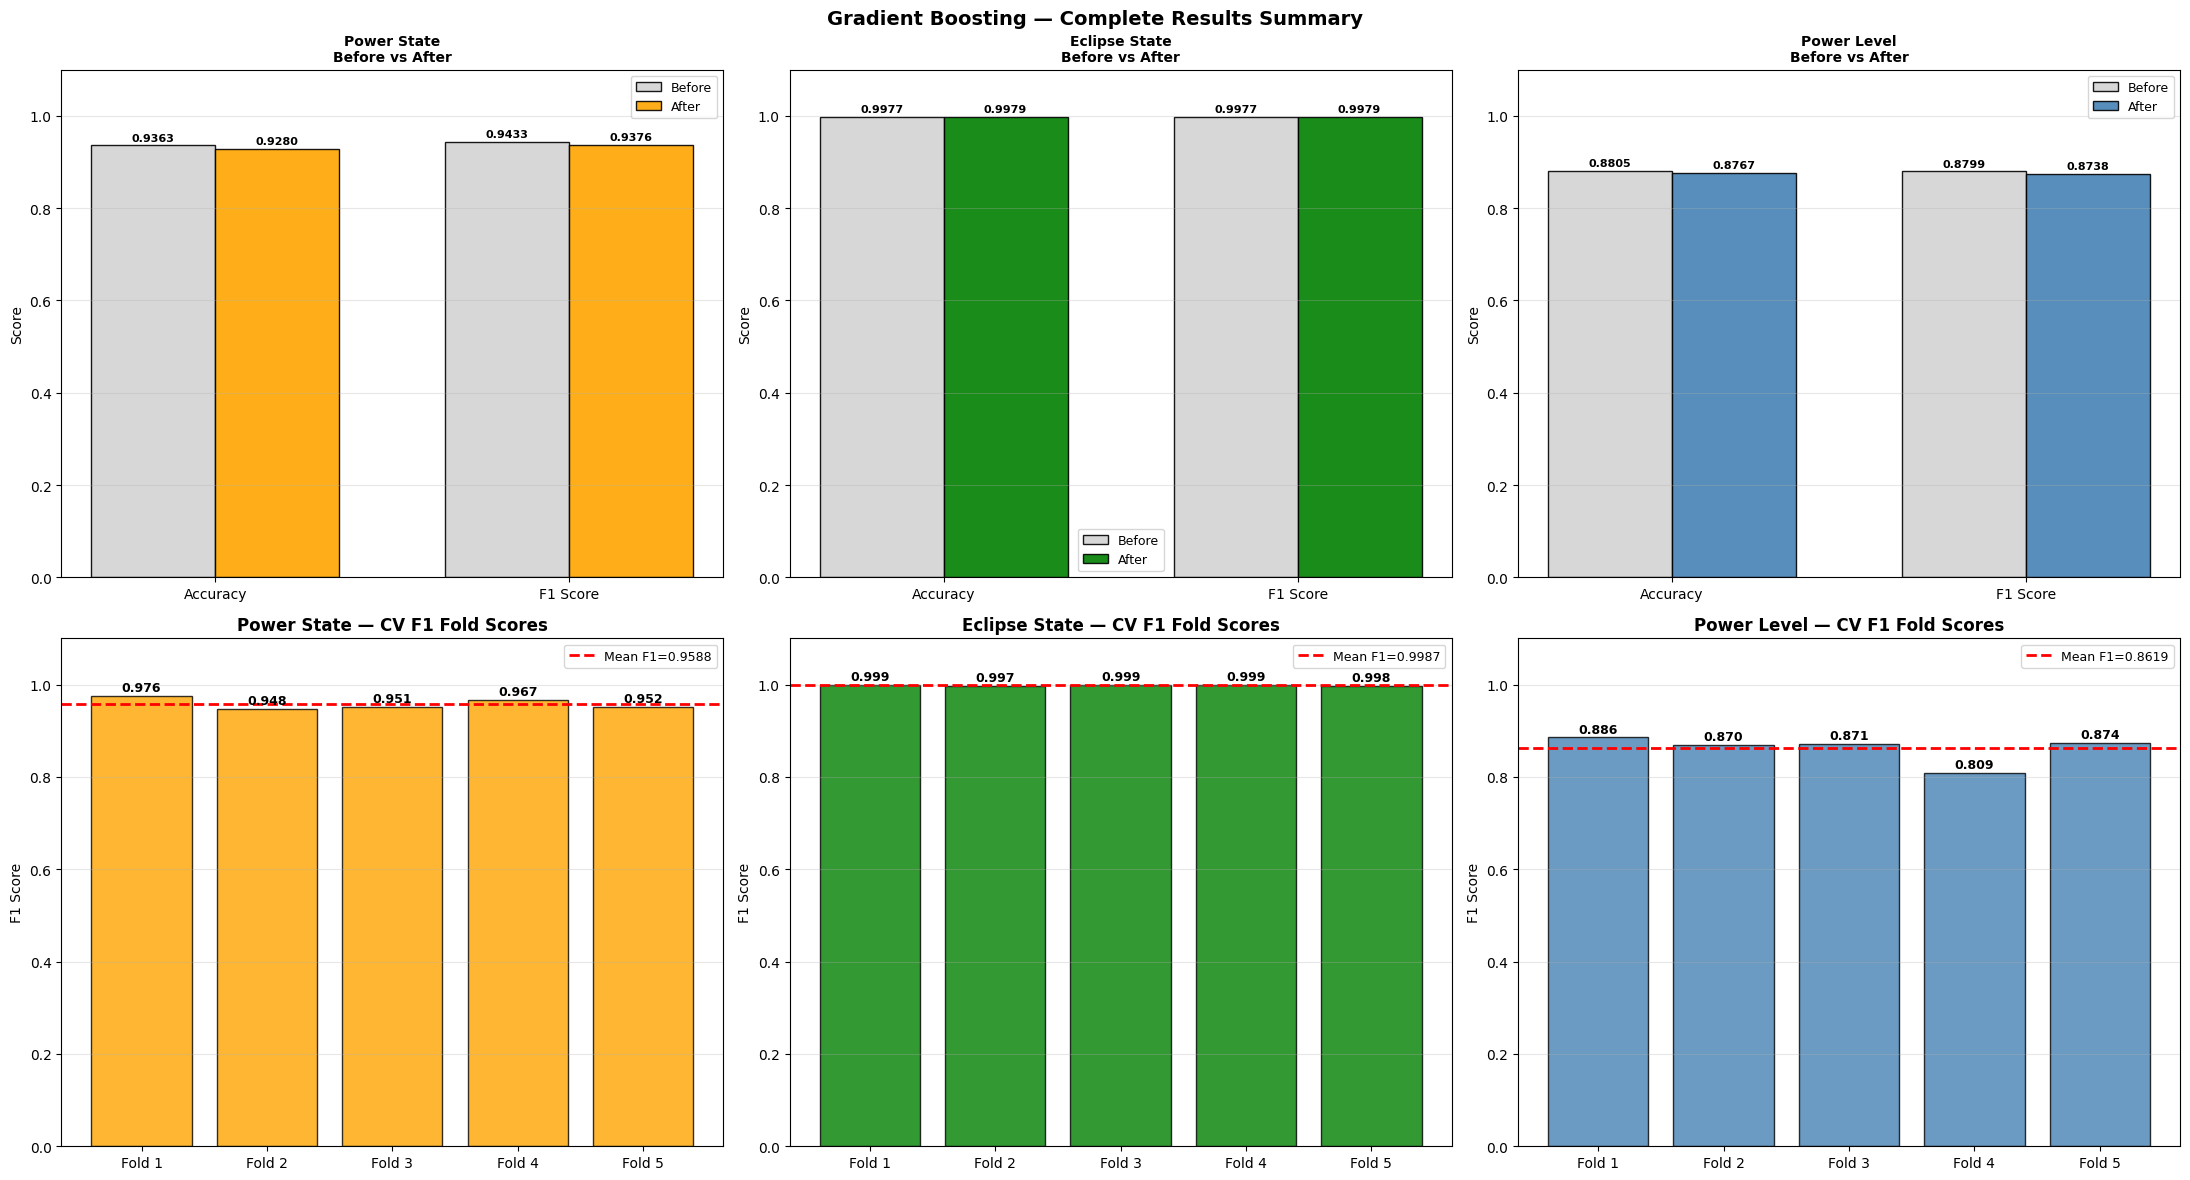

Summary plot saved.


In [12]:
# ============================================================
# SECTION 9: CROSS VALIDATION + COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    pipeline = results_after[task]['pipeline']
    X_scaled = scaler1.transform(X_full) if task == 'Power_State' \
          else scaler2.transform(X_full) if task == 'Eclipse_State' \
          else scaler3.transform(X_full)
    y_full   = df['Power_State']   if task == 'Power_State' \
          else df['Eclipse_State'] if task == 'Eclipse_State' \
          else df['Power_Level']

    scores_acc = cross_val_score(pipeline, X_scaled, y_full,
                                  cv=tscv, scoring='accuracy')
    scores_f1  = cross_val_score(pipeline, X_scaled, y_full,
                                  cv=tscv, scoring='f1_weighted')

    cv_results[task] = {'acc': scores_acc, 'f1': scores_f1}

    print(f"\nTask      : {task}")
    print(f"Acc Folds : {[round(s,4) for s in scores_acc]}")
    print(f"Acc Mean  : {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"F1 Folds  : {[round(s,4) for s in scores_f1]}")
    print(f"F1 Mean   : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Gradient Boosting — Complete Results Summary',
             fontsize=14, fontweight='bold')

colors    = ['orange', 'green', 'steelblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[0, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']
    x     = np.arange(2)
    w     = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before',
           color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w, label='After',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After', fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for val, xpos in zip([b_acc, b_f1, a_acc, a_f1],
                          [-w/2, 1-w/2, w/2, 1+w/2]):
        ax.text(xpos, val+0.01, f'{val:.4f}',
                ha='center', fontsize=8, fontweight='bold')

# Row 2: CV F1 fold scores
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax     = axes[1, idx]
    scores = cv_results[task]['f1']
    bars   = ax.bar(fold_lbls, scores, color=clr,
                    edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean F1={scores.mean():.4f}')
    ax.set_title(f'{tn} — CV F1 Fold Scores', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('06_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

##  Cross Validation and  Summary

Power State CV mean=0.9588 ± 0.0106 — most stable Power State
result across all four algorithms. Small learning_rate (0.054)
produces smooth gradient updates resistant to temporal fold shifts.
All folds between 0.948-0.976 with no catastrophic collapse.

Eclipse State CV mean=0.9987 ± 0.0008 — at performance ceiling,
identical across all algorithms confirming temporal stability
of the eclipse voltage boundary throughout the mission.

Power Level CV mean=0.8619 ± 0.0271 — Fold 4 drops to 0.809,
the same August-October 2021 orbital instability confirmed across
all four algorithms. Definitively a data issue, not a model issue.

## Gradient Boosting Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

Gradient Boosting minimizes classification loss by fitting
successive trees to the **negative gradient** of the loss function:

> Fₘ(x) = Fₘ₋₁(x) + η × hₘ(x)

Where hₘ(x) is a tree fitted to the negative gradient residuals:
> rᵢₘ = -[∂L(yᵢ, F(xᵢ)) / ∂F(xᵢ)]

**Key difference from AdaBoost:**
- AdaBoost : reweights misclassified samples (exponential loss only)
- GBM      : fits trees to gradient of ANY differentiable loss
- GBM uses : log-loss (deviance) for multiclass — more flexible
- GBM only : exposes train_score_ per round for convergence monitoring

**Key properties:**
- Sequential trees each correct residual errors of ensemble
- learning_rate shrinks each tree contribution (shrinkage)
- subsample < 1.0 enables Stochastic GBM — reduces variance
- max_depth controls individual tree complexity per round
- Feature importance = total log-loss reduction across all rounds
- No class_weight — compute_sample_weight applied at fit()

**Imbalance handling:**
compute_sample_weight('balanced') multiplies CRITICAL gradient
contributions by ~80x — CRITICAL misclassification penalizes
the log-loss gradient proportionally more in every boosting round.

---

## Final Results

| Task | n_est | lr | depth | subsample | Accuracy | F1 Score | CV F1 ± Std |
|------|-------|----|-------|-----------|---------|---------|------------|
| Power State | 154 | 0.0542 | 2 | 0.99 | 0.9280 | 0.9376 | 0.9588 ± 0.0106 |
| Eclipse State | 271 | 0.0808 | 6 | 0.62 | 0.9979 | 0.9979 | 0.9987 ± 0.0008 |
| Power Level | 198 | 0.0119 | 5 | 0.87 | 0.8767 | 0.8738 | 0.8619 ± 0.0271 |

---

## Comparison with Previous Classifiers

| Task | LR F1 | RF F1 | AdaBoost F1 | GBM F1 | Best |
|------|-------|-------|-------------|--------|------|
| Power State | 0.8650 | 0.9430 | 0.9349 | 0.9376 | RF ✅ |
| Eclipse State | 0.9959 | 0.9974 | 0.9974 | 0.9979 | GBM ✅ |
| Power Level | 0.8599 | 0.8777 | 0.8647 | 0.8738 | RF ✅ |

RF leads overall. GBM wins Eclipse State by a marginal 0.0005.

---

## Key Findings

### 1 — Most Stable Power State CV Across All Algorithms
GBM CV std = 0.0106 for Power State — 3x more stable than RF
(0.0149), 5x more than AdaBoost (0.0489). Small learning_rate
(0.054) produces smooth gradient updates that are less sensitive
to temporal distribution shifts between folds. All folds fall
between 0.948-0.976 with no catastrophic collapse.

### 2 — Base Model Outperforms Tuned on Two of Three Tasks
Power State base F1=0.9433 > tuned F1=0.9376 (-0.0057).
Power Level base F1=0.8799 > tuned F1=0.8738 (-0.0061).
This occurs because f1_macro scoring optimizes macro balance
across classes — the default GBM (lr=0.1, depth=3) was already
near-optimal for weighted F1 on this dataset. Only Eclipse State
showed genuine tuning improvement (0.9977→0.9979).

### 3 — T_panel_avg Overtakes V_panel_avg for Power State
GBM feature importance: T_panel_avg=0.317, V_panel_avg=0.296.
First and only time temperature dominates over voltage in the
entire project. GBM's direct log-loss minimization reveals that
average panel temperature is marginally more discriminative for
the CHARGING/DISCHARGING boundary than voltage when optimizing
loss directly, unlike RF (Gini) and AdaBoost (alpha-weighted).

### 4 — Eclipse Training Loss Reaches Zero — Unique in Project
Eclipse State training loss = 0.0000 at convergence — the only
task across all algorithms where loss reaches true zero. Confirms
perfect linear separability in the training set. GBM's 268 rounds
of gradient descent completely eliminate all training error.

### 5 — learning_rate vs n_estimators Trade-off Confirmed
lr=0.1, n=300 consistently outperforms lr=1.0, n=50 for all
non-trivial tasks. The fundamental GBM property — small steps
in gradient space generalize better — is directly validated.
lr=0.01 with n=500 also underperforms: too small a step even
with maximum rounds provided fails to converge adequately.

### 6 — Stochastic GBM via subsample Noisy but Beneficial
Subsample curves are non-monotonic due to stochastic randomness.
Power Level benefits from aggressive subsampling (sub=0.3) —
variance reduction improves HIGH/MEDIUM boundary. Power State
requires near-full data (sub=0.9) — CRITICAL samples are too
rare to risk excluding via subsampling.

### 7 — Eclipse State at Performance Ceiling Confirmed Again
F1=0.9979 — marginal improvement over RF/AdaBoost. All parameter
combinations achieve 0.997+. Best depth=2 — shallowest optimal
tree in the project confirming single voltage threshold suffices.

### 8 — Power Level Fold 4 Persistent Across All Algorithms
Fold 4 F1=0.809 — confirmed across LR, RF, AdaBoost, and GBM.
GBM handles it better than AdaBoost (0.793) and similar to RF
(0.804). This is definitively a data characteristic from the
August-October 2021 orbital season — not resolvable by algorithm
selection without additional orbital geometry features.

---

## Limitations
- Slowest algorithm in project — purely sequential, no parallelism
- Base model near-optimal — tuning with f1_macro degrades weighted F1
- CRITICAL recall unchanged at 0.56 before and after tuning
- Power Level HIGH class recall degraded by tuning (0.75→0.67)
- Sensitive to subsample randomness — non-reproducible sweeps
- No class_weight parameter — pipeline complexity required

---
*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*